# 15.4.1 数据、方程与初值的分项损失

## 学习目标与先修知识

对光滑候选函数计算导数（derivative）与方程残差（residual），分开报告数据、物理和初值（initial condition）误差。

先修：15.1 自动微分（automatic differentiation，AD）；15.3 连续右端；平方损失。

## 具体问题

用少量观测（observation）拟合衰减曲线，候选函数可以穿过观测点却不满足已知清除方程。怎样把这两种误差分开检查？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
t=.5;c,v,w,b=.8,.5,-1.,0.;z=np.tanh(w*t+b);print("候选值与导数：",c+v*z,v*w*(1-z*z))

候选值与导数： 0.5689414213699951 -0.3932238664829637


## 模型假设

已知教学方程 $x^\prime=-kx$，$k=0.7/T$；候选函数 $\phi(t)=c+v\tanh(wt+b)$，输入（input）时间以 T 为数值单位。$w$ 单位 1/T，$c,v$ 单位 U。观测点、配点（collocation point）与独立评估网格分开；本节只扫描小型候选，不宣称训练出一般神经网络（neural network）模型。

## 数学解释与推导

物理信息神经网络（physics-informed neural network，PINN）用可微函数表示候选解，并在配点上评价微分方程残差；本节把函数族缩到一个可手算的 tanh 神经元。$\phi^\prime(t)=vw[1-\tanh^2(wt+b)]$，方程残差 $r(t)=\phi^\prime(t)+k\phi(t)$，单位 U/T。分别定义 $L_d=N_d^{-1}\sum(\phi(t_i)-y_i)^2$（U²），$L_f=N_f^{-1}\sum r(s_j)^2$（U²/T²），$L_0=[\phi(0)-x_0]^2$（U²）。加权求和前应按预先声明的尺度无量纲化（nondimensionalization）；本节展示三个原始分项，不把相加后的数值当作普遍物理误差。有限配点残差小，不等于全时间域解误差小。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def tanh_trial(t, c, v, w, b):
    z = math.tanh(w*t+b)
    return c+v*z, v*w*(1-z*z)


def ode_loss_parts(times, observed, k, c, v, w, b, initial):
    """Mean data/residual loss and initial-state loss, each kept separate."""
    values = [tanh_trial(float(t), c, v, w, b) for t in times]
    data = sum((state-float(y))**2 for (state,_),y in zip(values,observed))/len(times)
    physics = sum((slope+k*state)**2 for state,slope in values)/len(times)
    boundary = (tanh_trial(0.,c,v,w,b)[0]-initial)**2
    return [float(data),float(physics),float(boundary)]

## 对照实验

改变已声明的条件并比较曲线与数值。

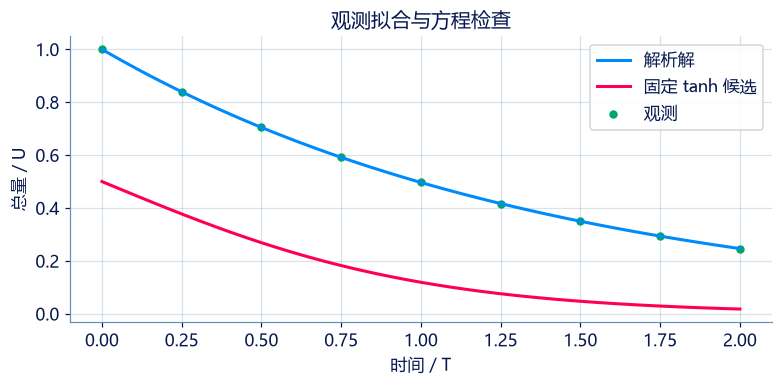

数据、方程、初值分项： [0.14367087785070443, 0.018294062907765547, 0.25]


In [4]:
k=.7;x0=1.;times=np.linspace(0,2,9);observed=np.exp(-k*times);params=(.5,.5,-1.,0.)
parts=ode_loss_parts(times,observed,k,*params,x0);grid=np.linspace(0,2,101);candidate=np.array([tanh_trial(t,*params)[0] for t in grid]);truth=np.exp(-k*grid)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(grid,truth,label="解析解",color=BLUE);ax.plot(grid,candidate,label="固定 tanh 候选",color=PINK);ax.scatter(times,observed,color=GREEN,label="观测",s=20);ax.set(xlabel="时间 / T",ylabel="总量 / U",title="观测拟合与方程检查");ax.legend();ax.grid(alpha=.25);plt.show()
print("数据、方程、初值分项：",parts)

## 结果解释

候选在部分观测附近可能接近解析曲线，但方程与初值残差仍提供不同证据。改变权重会改变优化目标；所有分项均需保留以便解释。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
state,slope=tanh_trial(.5,*params)
np.testing.assert_allclose(slope,(tanh_trial(.5+1e-5,*params)[0]-tanh_trial(.5-1e-5,*params)[0])/(2e-5),rtol=1e-9)
manual=np.mean([(tanh_trial(t,*params)[1]+k*tanh_trial(t,*params)[0])**2 for t in times])
np.testing.assert_allclose(parts[1],manual)
assert parts[2]>=0 and np.all(np.isfinite(candidate))
print("解析导数经中心差分和逐点残差独立核验。")

解析导数经中心差分和逐点残差独立核验。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：方程约束的三类证据

少量观测（observation）上数据损失接近零，能推出什么？

- **A.** 候选函数在连续全域满足方程。
- **B.** 初值（initial condition）自动正确。
- **C.** 训练外轨迹（trajectory）一定正确。
- **D.** 只说明给定观测点拟合好；仍要查残差（residual）、初值和独立点。

[作答：方程约束的三类证据](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/practice/?question=p15-pinn-parts)

### 第 2 题 · 单项选择题：损失相加之前

数据平方误差的单位是 U²，方程残差（residual）平方的单位是 U²/T²。直接相加前应怎样做？

- **A.** 声明尺度与权重，最好先无量纲化（nondimensionalization）各分项。
- **B.** 把单位写在图例里就足够。
- **C.** 只删除方程项。
- **D.** 只增加配点（collocation point）数。

[作答：损失相加之前](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/practice/?question=p15-loss-unit)

### 第 3 题 · Python 计算题：光滑候选值与导数

返回单神经元候选在时刻 t 的值和时间导数（derivative）。

**函数与代码模板**

```python
def solve(
    t: float,
    c: float,
    v: float,
    w: float,
    b: float,
) -> tuple[float, float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `t` | `float` | 非负时间。 | T |
| `c` | `float` | 常量项。 | U |
| `v` | `float` | tanh 幅度。 | U |
| `w` | `float` | 时间系数。 | 1/T |
| `b` | `float` | 无量纲（dimensionless）偏置。 | 1 |

**返回值**

按以下顺序返回元组：(value, derivative)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `value` | `float` | 候选函数值。 | U |
| `derivative` | `float` | 时间导数。 | U/T |

**计算规则**

候选值 c+v*tanh(w*t+b)，时间导数 v*w*(1-tanh(w*t+b)²)。

**约束与边界**

- 输入（input）规模不超过100，全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| t | 非负时间。 | 0 | T |
| c | 常量项。 | 1 | U |
| v | tanh 幅度。 | 2 | U |
| w | 时间系数。 | 0.5 | 1/T |
| b | 无量纲（dimensionless）偏置。 | 0 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
t = 0.0
c = 1.0
v = 2.0
w = 0.5
b = 0.0

result = solve(t, c, v, w, b)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| value | 候选函数值。 | 1 | U |
| derivative | 时间导数。 | 1 | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.0, 1.0)
```

**样例解释**

首例 tanh(0)=0，导数为 v·w。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：光滑候选值与导数](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/practice/?question=p15-trial-derivative)

### 第 4 题 · Python 计算题：数据、方程与初值损失

给定相同长度的配点（collocation point）与观测（observation），返回三个未加权损失分项。

**函数与代码模板**

```python
def solve(
    times: list[float],
    observed: list[float],
    k: float,
    c: float,
    v: float,
    w: float,
    b: float,
    initial: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 配点时刻。 | T |
| `observed` | `list[float]` | 对应观测总量。 | U |
| `k` | `float` | 已知消除系数。 | 1/T |
| `c` | `float` | 候选常量项。 | U |
| `v` | `float` | tanh 幅度。 | U |
| `w` | `float` | 时间系数。 | 1/T |
| `b` | `float` | 偏置。 | 1 |
| `initial` | `float` | 声明的初始总量。 | U |

**返回值**

直接返回 parts（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `parts` | `list[float]` | 依次为数据均方、方程残差（residual）均方、初值（initial condition）平方误差。 | 依分项 |

**计算规则**

数据项是候选与 observed 的差的平方平均；方程项是 (候选导数（derivative）+k*候选)² 的平均；初值项是 (候选(0)-initial)²。

**约束与边界**

- 配点与观测等长且至少一个，全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 配点时刻。 | [0.0, 1.0] | T |
| observed | 对应观测总量。 | [1.0, 1.0] | U |
| k | 已知消除系数。 | 0.5 | 1/T |
| c | 候选常量项。 | 1 | U |
| v | tanh 幅度。 | 0 | U |
| w | 时间系数。 | 1 | 1/T |
| b | 偏置。 | 0 | 1 |
| initial | 声明的初始总量。 | 1 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0.0, 1.0]
observed = [1.0, 1.0]
k = 0.5
c = 1.0
v = 0.0
w = 1.0
b = 0.0
initial = 1.0

result = solve(times, observed, k, c, v, w, b, initial)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| parts | 依次为数据均方、方程残差（residual）均方、初值（initial condition）平方误差。 | [0.0, 0.25, 0.0] | 依分项 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 0.25, 0.0]
```

**样例解释**

首例候选恒为1，数据与初值损失为0，方程残差每点为0.5。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：数据、方程与初值损失](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/practice/?question=p15-ode-loss-parts)

**进一步阅读**

[Raissi 等的 PINN 论文](https://www.sciencedirect.com/science/article/pii/S0021999118307125)给出数据与方程约束的训练形式；此处只用可手算一神经元候选。